# Klasifikasi & Analisis Rambut (Computer Vision) — RAG Salon

**Proyek:** Multimodal RAG + Computer Vision untuk Salon **TIEN SALON**  
**Bagian:** Computer Vision (CV) — *versi FINAL*

---

## Deskripsi

Notebook ini mereproduksi **pipeline Computer Vision end-to-end** untuk analisis foto rambut,
mulai dari *gate* pose (viewpoint) → preprocessing → training → evaluasi.

Notebook ini adalah **versi final/rapi** (bukan eksperimen). Skrip eksperimen tetap tersimpan
sebagai berkas `.py` di folder modul (`hair_type/`, `hair_length/`, `viewpoint/`, `scripts/`).

## Struktur Notebook

| Bagian | Section | Isi |
|---|---|---|
| **1. Setup** | 1–2 | Konfigurasi, imports, verifikasi environment (torch/GPU) |
| **2. Viewpoint Gate** | 3–4 | Gate pose MediaPipe (foto harus tampak belakang), evaluasi |
| **3. Data & EDA** | 5–6 | Struktur dataset, distribusi kelas, contoh gambar |
| **4. Preprocessing** | 7 | Transform train vs val (ImageNet norm + augmentasi) |
| **5. Model + Training** | 8–10 | hair_type (MobileNetV2), hair_length (EfficientNetV2-S + benchmark) |
| **6. Evaluasi** | 11–13 | Confusion matrix, per-class metrics, separability, perbandingan metode |
| **7. Diagnosis** | 14–15 | Analisis **overfitting** (gap train-val) & **overconfidence** (kalibrasi/ECE) |
| **8. Kesimpulan** | 16 | Ringkasan hasil & future work |

> ⚠️ **Penting — hold-out asli.** Evaluasi memakai folder `preprocessed/val/` dan split `val` dari
> `index_merged.json` sebagai **hold-out asli**, BUKAN hasil split ulang dari data training.
> Training merekam **train_acc, train_loss, val_acc, val_loss** agar **gap overfitting** terlihat.

> **Catatan environment:** Notebook ini memakai kernel **Python 3.13 (venv CUDA)** yang sudah punya
> `torch`+CUDA, `torchvision`, `sklearn`, `matplotlib`, `seaborn`, `pandas`, `opencv`. Bagian yang
> memerlukan `mediapipe` (viewpoint gate heuristik) atau `onnxruntime` (export/eval ONNX) akan
> **degradasi dengan anggun** — jika paket tidak tersedia, notebook menampilkan hasil tersimpan,
> bukan gagal.


---
# Bagian 1 — Setup
## Section 1 — Konfigurasi & Imports

Bagian ini menyiapkan: **seed reproducibility**, konstanta preprocessing (ImageNet statistics),
**path proyek**, dan seluruh library yang dipakai. Semua konstanta diambil agar **konsisten**
dengan modul produksi (`common/constants.py`) sehingga hasil notebook = hasil pipeline nyata.


In [1]:
from __future__ import annotations

import json
import os
import random
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Seed untuk reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Normalisasi ImageNet (standar transfer learning) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Ukuran gambar (konsisten dengan modul preprocessing) ---
INPUT_SIZE  = 224   # output crop
RESIZE_SIDE = 256   # sisi pendek sebelum center-crop

# --- Path proyek (deteksi otomatis: notebook ada di apps/api/cv/notebooks) ---
CWD = Path.cwd().resolve()
def _find_cv_dir(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "common" / "constants.py").exists() and (p / "hair_type").exists():
            return p
    # fallback: anggap notebook di apps/api/cv/notebooks
    cand = start.parent if (start / "notebooks").exists() else start
    return cand

CV_DIR = _find_cv_dir(CWD)
sys.path.insert(0, str(CV_DIR))
print("CV_DIR =", CV_DIR)
print("Python =", sys.version.split()[0])


CV_DIR = C:\laragon\www\RAG-salon\apps\api\cv
Python = 3.13.3


## Section 2 — Verifikasi Environment

Memastikan `torch`, `torchvision`, dan **ketersediaan CUDA/GPU**. Training di notebook ini
menjalankan epoch penuh — GPU sangat disarankan (CPU tetap jalan tapi jauh lebih lambat).


In [2]:
import importlib

def has(mod: str) -> str:
    try:
        m = importlib.import_module(mod)
        return getattr(m, "__version__", "?")
    except Exception:
        return "TIDAK ADA"

print(f"torch        : {has('torch')}")
print(f"torchvision  : {has('torchvision')}")
print(f"mediapipe    : {has('mediapipe')}   (dipakai viewpoint gate)")
print(f"onnxruntime  : {has('onnxruntime')}   (dipakai export/eval ONNX)")
print(f"sklearn      : {has('sklearn')}")
print(f"seaborn      : {has('seaborn')}")
print(f"opencv       : {has('cv2')}")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models
from torchvision.transforms import InterpolationMode

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("\nDEVICE =", DEVICE)
if torch.cuda.is_available():
    print("GPU    =", torch.cuda.get_device_name(0))


torch        : 2.12.0+cu126


torchvision  : 0.27.0+cu126
mediapipe    : TIDAK ADA   (dipakai viewpoint gate)
onnxruntime  : TIDAK ADA   (dipakai export/eval ONNX)
sklearn      : 1.8.0
seaborn      : 0.13.2
opencv       : 5.0.0

DEVICE = cuda
GPU    = NVIDIA GeForce RTX 3050 Laptop GPU


---
# Bagian 2 — Viewpoint Gate (Tahap 0)
## Section 3 — Konsep & Hasil Tersimpan

**Tujuan gate:** memastikan foto diambil dari **arah belakang** (viewpoint), karena hanya foto
belakang yang layak dianalisis jenis & panjang rambut. Foto depan/samping → diminta foto ulang.

Gate memakai **heuristik MediaPipe** (FaceLandmarker + PoseLandmarker): mendeteksi posisi wajah,
telinga, bahu, siku. Vonis 3 kelas: `depan`, `samping`, `belakang`; hanya `belakang` lolos.

Karena `mediapipe` tidak tersedia di kernel CUDA ini, Section ini **menampilkan hasil evaluasi
yang sudah tersimpan** (`viewpoint/reports/*.json`). Kode heuristik lengkap ada di `viewpoint/gate.py`.


In [3]:
# Tampilkan hasil evaluasi viewpoint yang sudah tersimpan (hasil gate vs verifikasi manusia)
vp_report = CV_DIR / "viewpoint" / "reports" / "viewpoint_accuracy.json"

if vp_report.exists():
    acc = json.loads(vp_report.read_text(encoding="utf-8"))
    print("== Laporan akurasi Viewpoint Gate (gate heuristik vs verifikasi manusia) ==")
    print(json.dumps(acc, indent=2, ensure_ascii=False)[:1500])
else:
    print("Laporan viewpoint belum ada:", vp_report)


== Laporan akurasi Viewpoint Gate (gate heuristik vs verifikasi manusia) ==
{
  "analysis": "viewpoint_accuracy_asmode",
  "mode": "pengukuran (as-is)",
  "timestamp": "2026-09-18T07:03:14.692872+00:00",
  "annotators": [
    "A"
  ],
  "n_verified": 193,
  "n_per_annotator": {
    "A": 193
  },
  "metrics": {
    "accuracy": 0.8031,
    "accuracy_excluding_ragu": 0.8378,
    "n_correct": 155,
    "n_wrong": 30,
    "n_ragu": 8,
    "ragu_rate": 0.0415
  },
  "accuracy_per_predicted_class": {
    "depan": {
      "n": 41,
      "correct": 30,
      "accuracy": 0.7317
    },
    "samping": {
      "n": 19,
      "correct": 13,
      "accuracy": 0.6842
    },
    "belakang": {
      "n": 133,
      "correct": 112,
      "accuracy": 0.8421
    }
  },
  "confusion_model_to_human": {
    "belakang": {
      "belakang_nyerong": 1,
      "depan": 5,
      "samping": 10
    },
    "depan": {
      "samping": 3,
      "depan": 3,
      "belakang": 4
    }
  }
}


Lewati visualisasi: unhashable type: 'dict'


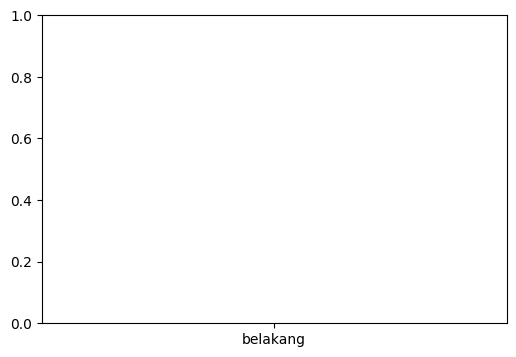

In [4]:
# Visualisasi akurasi per-kelas viewpoint (jika tersedia)
try:
    acc = json.loads((CV_DIR / "viewpoint" / "reports" / "viewpoint_accuracy.json").read_text(encoding="utf-8"))
    # cari dict per-kelas dalam struktur apa pun
    def find_perclass(d):
        if isinstance(d, dict):
            if all(k in d for k in ("belakang",)) and any(k in d for k in ("depan", "samping")):
                return d
            for v in d.values():
                r = find_perclass(v)
                if r: return r
        return None
    pc = find_perclass(acc)
    if pc:
        labels = [k for k in ("belakang", "depan", "samping") if k in pc]
        vals = [pc[k] for k in labels]
        plt.figure(figsize=(6,4))
        bars = plt.bar(labels, vals, color=["#2E7D32","#C62828","#EF6C00"])
        plt.ylim(0,1); plt.title("Akurasi Viewpoint Gate per Kelas")
        plt.ylabel("Akurasi")
        for b,v in zip(bars, vals):
            plt.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center")
        plt.tight_layout(); plt.show()
    else:
        print("Struktur per-kelas tidak ditemukan; lihat JSON di atas.")
except Exception as e:
    print("Lewati visualisasi:", e)


In [5]:
# (Opsional) Jalankan gate heuristik bila mediapipe tersedia.
# Jika tidak, sel ini hanya memberi tahu & tidak gagal (graceful).
run_gate = False
if has("mediapipe") != "TIDAK ADA":
    run_gate = True
    import subprocess
    print("mediapipe tersedia. Menjalankan viewpoint/gate.py --source figaro --all ...")
    r = subprocess.run([sys.executable, str(CV_DIR / "viewpoint" / "gate.py"),
                        "--source", "figaro", "--all"],
                       cwd=str(CV_DIR), capture_output=True, text=True)
    print(r.stdout[-2000:])
    if r.returncode != 0:
        print("stderr:", r.stderr[-1000:])
else:
    print("mediapipe tidak tersedia di kernel ini — gate heuristik dilewati (lihat hasil tersimpan di atas).")
    print("Untuk menjalankan gate: pakai venv apps/api/cv/.venv lalu `python viewpoint/gate.py --source figaro --all`.")


mediapipe tidak tersedia di kernel ini — gate heuristik dilewati (lihat hasil tersimpan di atas).
Untuk menjalankan gate: pakai venv apps/api/cv/.venv lalu `python viewpoint/gate.py --source figaro --all`.


## Section 4 — CNN Viewpoint (Opsional)

Selain heuristik, ada pendekatan **CNN** (EfficientNetV2-S) untuk klasifikasi viewpoint.
Evaluasi perbandingan CNN vs heuristik tersimpan di `viewpoint/reports/viewpoint_cnn_vs_heuristic.json`.


In [6]:
for fname in ["viewpoint_cnn_vs_heuristic.json", "viewpoint_cnn_train.json"]:
    p = CV_DIR / "viewpoint" / "reports" / fname
    if p.exists():
        print(f"== {fname} ==")
        print(json.dumps(json.loads(p.read_text(encoding="utf-8")), indent=2, ensure_ascii=False)[:1200])
        print()
    else:
        print(f"(tidak ada: {fname})")


(tidak ada: viewpoint_cnn_vs_heuristic.json)
(tidak ada: viewpoint_cnn_train.json)


---
# Bagian 3 — Data & EDA
## Section 5 — Struktur Dataset

Notebook ini memakai **dua dataset terpisah**, sesuai tugas masing-masing:

| Tugas | Dataset | Sumber | Kelas | Path |
|---|---|---|---|---|
| **Jenis rambut** (hair_type) | **FIGARO 1k (partisi salon)** | *FIGARO-only* | lurus, bergelombang, keriting, sangat-keriting | `preprocessed/train|val/<kelas>/*.pt` |
| **Panjang rambut** (hair_length) | length dataset (hs40 + bald) | non-FIGARO | pendek, pendek-menengah, menengah, panjang | `preprocessed_length_merged/index_merged.json` |

> **Kenapa hair_type FIGARO-only?** FIGARO 1k adalah dataset publik berlisensi yang menyediakan
> label **jenis rambut**. Kita memakai **hanya** partisi salon 4 kelas (150 citra/kelas) agar
> target kelas seimbang. Dataset lain (mis. `extra/`, `hair_length_geometris/`) **tidak** dipakai
> untuk hair_type.
>
> **Kenapa hair_length BUKAN FIGARO?** FIGARO 1k **tidak memiliki label panjang rambut**. Karena itu
> panjang rambut dilatih dari dataset panjang tersendiri (sumber `hs40` + `bald`), dan kita **buang**
> entri bersumber `figaro` dari index length untuk mencegah kebocoran (leakage).

Karena `preprocessed/index.json` tidak ada, kita **bangun index** dari struktur folder secara
otomatis, lalu **memverifikasi provenance-nya adalah FIGARO**.


In [7]:
HAIR_TYPE_CLASSES   = ["lurus", "bergelombang", "keriting", "sangat-keriting"]
HAIR_LENGTH_CLASSES = ["pendek", "pendek-menengah", "menengah", "panjang"]

# ---- Bangun index hair_type dari struktur folder preprocessed/{train,val}/<kelas>/*.pt ----
# Sumber tensor = FIGARO 1k partisi salon (150 citra/kelas). Tidak ada dataset lain di sini.
def build_type_index():
    recs = {"train": [], "val": []}
    base = CV_DIR / "preprocessed"
    for split in ("train", "val"):
        for cls in HAIR_TYPE_CLASSES:
            d = base / split / cls
            if not d.exists():
                continue
            for f in sorted(d.glob("*.pt")):
                rel = f.relative_to(CV_DIR).as_posix()
                recs[split].append({"pt": rel, "kelas": cls})
    return recs

type_index = build_type_index()
print("hair_type — train:", len(type_index["train"]), "val:", len(type_index["val"]))

# distribusi train per kelas
cnt_train = Counter(r["kelas"] for r in type_index["train"])
cnt_val   = Counter(r["kelas"] for r in type_index["val"])
print("\nTrain per kelas:", dict(cnt_train))
print("Val   per kelas:", dict(cnt_val))

# ---- Verifikasi provenance: hair_type HARUS FIGARO-only & tidak pakai dataset ekstra ----
# Bukti 1: laporan preprocessing menyatakan sumber = figaro1k.
_report = CV_DIR / "preprocessed" / "_preprocess_report.json"
if _report.exists():
    _rep = json.loads(_report.read_text(encoding="utf-8"))
    _src = str(_rep.get("dataset", "")).lower()
    assert "figaro" in _src, f"preprocessing report BUKAN figaro: {_src!r}"
    print("\n[OK] Provenance preprocessing:", _rep.get("dataset"))
else:
    print("\n(!) _preprocess_report.json tidak ada — lewati cek laporan.")

# Bukti 2: tidak ada kelas/folder dari dataset non-FIGARO (extra/, hair_length_geometris/)
_used_classes = set(cnt_train) | set(cnt_val)
assert _used_classes == set(HAIR_TYPE_CLASSES), (
    f"kelas tak terduga (dataset non-FIGARO ikut masuk?): {_used_classes - set(HAIR_TYPE_CLASSES)}"
)
print("[OK] hair_type FIGARO-only:", sorted(_used_classes))
print("[OK] Dataset lain (extra/, hair_length_geometris/) TIDAK dipakai untuk hair_type.")


hair_type — train: 1440 val: 120

Train per kelas: {'lurus': 360, 'bergelombang': 360, 'keriting': 360, 'sangat-keriting': 360}
Val   per kelas: {'lurus': 30, 'bergelombang': 30, 'keriting': 30, 'sangat-keriting': 30}

[OK] Provenance preprocessing: figaro1k (partisi salon 4 kelas)
[OK] hair_type FIGARO-only: ['bergelombang', 'keriting', 'lurus', 'sangat-keriting']
[OK] Dataset lain (extra/, hair_length_geometris/) TIDAK dipakai untuk hair_type.


In [8]:
# ---- Index hair_length dari index_merged.json (buang sumber figaro agar tidak leakage) ----
merged_path = CV_DIR / "preprocessed_length_merged" / "index_merged.json"
merged = json.loads(merged_path.read_text(encoding="utf-8"))
length_entries = [e for e in (merged["index"]["train"] + merged["index"]["val"]) if e.get("sumber") != "figaro"]
cnt_len = Counter(e["kelas"] for e in length_entries)
print("hair_length — total (tanpa figaro):", len(length_entries))
print("Per kelas:", dict(cnt_len))
print("\nContoh entry:", length_entries[0])


hair_length — total (tanpa figaro): 1497
Per kelas: {'menengah': 150, 'panjang': 240, 'pendek': 839, 'pendek-menengah': 268}

Contoh entry: {'pt': 'preprocessed_length_merged/train/menengah/hs40_menengah_00001.pt', 'kelas': 'menengah', 'sumber': 'hs40', 'asal': 'hs40_LayeredHair_01'}


## Section 6 — EDA: Distribusi Kelas & Contoh Gambar

EDA menampilkan **keseimbangan kelas** (penting karena ada kelas minoritas → memengaruhi strategi
class-weight) dan **contoh gambar** tiap kelas.

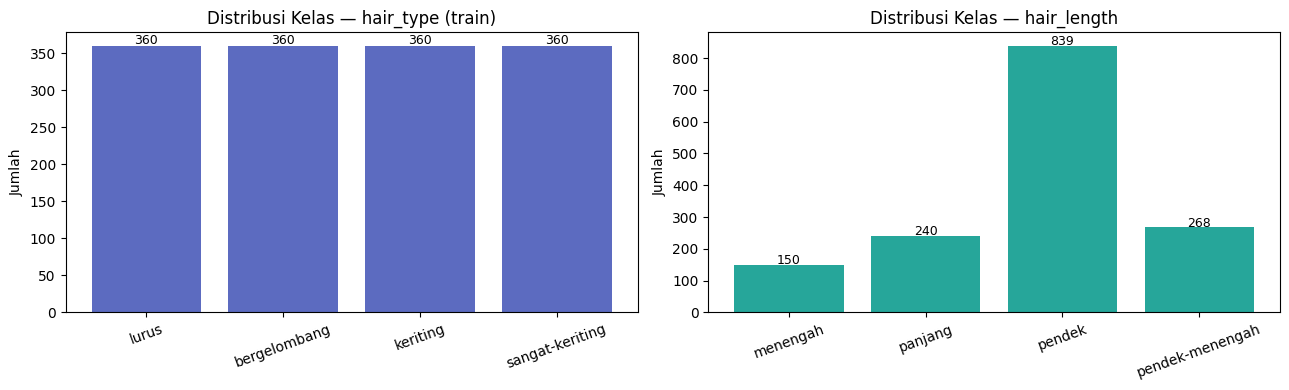

Rasio imbalance hair_length = 5.59 : 1


In [9]:
# Bar chart distribusi kelas (hair_type & hair_length)
fig, axes = plt.subplots(1, 2, figsize=(13,4))

# hair_type
names_t = list(cnt_train.keys()); vals_t = [cnt_train[k] for k in names_t]
axes[0].bar(names_t, vals_t, color="#5C6BC0")
axes[0].set_title("Distribusi Kelas — hair_type (train)")
axes[0].set_ylabel("Jumlah"); axes[0].tick_params(axis='x', rotation=20)
for i,v in enumerate(vals_t): axes[0].text(i, v+2, str(v), ha="center", fontsize=9)

# hair_length
names_l = list(cnt_len.keys()); vals_l = [cnt_len[k] for k in names_l]
axes[1].bar(names_l, vals_l, color="#26A69A")
axes[1].set_title("Distribusi Kelas — hair_length")
axes[1].set_ylabel("Jumlah"); axes[1].tick_params(axis='x', rotation=20)
for i,v in enumerate(vals_l): axes[1].text(i, v+2, str(v), ha="center", fontsize=9)

plt.tight_layout(); plt.show()

# Rasio imbalance
print("Rasio imbalance hair_length = %.2f : 1" % (max(vals_l)/min(vals_l)))


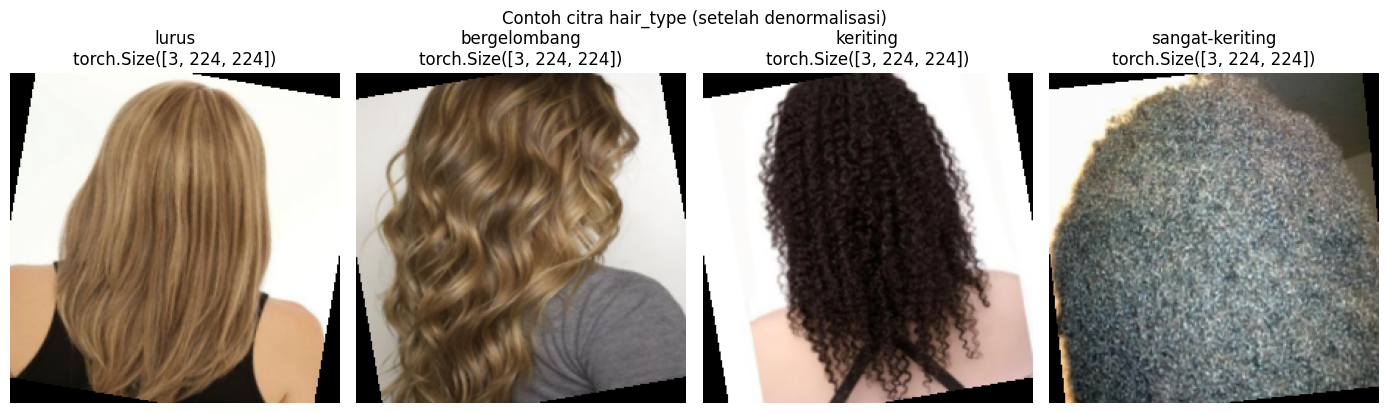

In [10]:
# Contoh gambar: denormalisasi tensor .pt untuk ditampilkan
import torch
from PIL import Image

MEAN = torch.tensor(IMAGENET_MEAN).view(3,1,1)
STD  = torch.tensor(IMAGENET_STD).view(3,1,1)

def tensor_to_img(t):
    t = t * STD + MEAN          # denormalisasi
    t = t.clamp(0,1)
    return t.permute(1,2,0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, cls in zip(axes, HAIR_TYPE_CLASSES):
    sample = next((r for r in type_index["train"] if r["kelas"] == cls), None)
    if sample:
        t = torch.load(CV_DIR / sample["pt"], weights_only=True).squeeze(0)
        ax.imshow(tensor_to_img(t))
        ax.set_title(f"{cls}\n{t.shape}"); ax.axis("off")
plt.suptitle("Contoh citra hair_type (setelah denormalisasi)", y=1.02)
plt.tight_layout(); plt.show()


---
# Bagian 4 — Preprocessing
## Section 7 — Transform Train vs Val

**Pipeline:** RGB → EXIF-transpose → resize keep-aspect (256) → center-crop 224 → Normalize ImageNet → NCHW float32.

**Augmentasi (hanya saat training, mobile):**
- Flip horizontal `p=0.5`
- Jitter brightness/contrast `t·U(0.9,1.1)+U(-0.1,0.1)` dengan `p=0.6` (khusus hair_length)

**Val/inference tanpa augmentasi** agar metrik konsisten.

> Catatan: dataset `.pt` sudah **ternormalisasi & ter-augmentasi** saat pembuatan dataset.
> Augmentasi di bawah diterapkan *on-the-fly* pada tensor (konsisten dengan `train.py`).

In [11]:
# Transform referensi (dokumentasi pipeline) — bila ingin membangun dari citra mentah
def train_transforms():
    return transforms.Compose([
        transforms.RandomResizedCrop((INPUT_SIZE, INPUT_SIZE), scale=(0.875, 1.0),
                                     ratio=(3/4, 4/3),
                                     interpolation=InterpolationMode.BILINEAR, antialias=True),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def val_transforms():
    return transforms.Compose([
        transforms.Resize(RESIZE_SIDE, interpolation=InterpolationMode.BILINEAR, antialias=True),
        transforms.CenterCrop(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

print("Pipeline preprocessing siap.")
print("  train: RandomResizedCrop + Flip + Rotation + Normalize")
print("  val  : Resize(256) + CenterCrop(224) + Normalize")


Pipeline preprocessing siap.
  train: RandomResizedCrop + Flip + Rotation + Normalize
  val  : Resize(256) + CenterCrop(224) + Normalize


---
# Bagian 5 — Model & Training
## Section 8 — Pendahuluan

Dua model terpisah (transfer learning dari ImageNet):

| Tugas | Backbone | Head | Epoch | Optimizer | Loss |
|---|---|---|---|---|---|
| **hair_type** | MobileNetV2 | Dropout(0.5)+Linear(4) | 12 | Adam (lr 1e-3, wd 1e-4) | CrossEntropy |
| **hair_length** | EfficientNetV2-S | Dropout(0.3)+Linear(4) | 40 | AdamW + CosineAnnealing | CE (class-weight + label_smoothing 0.08) |

**hair_length** memakai trik: *freeze* backbone 3 epoch (warmup) → *unfreeze* fine-tune penuh,
serta **class weight** (inverse frequency) untuk menangani imbalance.

### Section 9 — Training: hair_type (MobileNetV2)

Latihan penuh 12 epoch. Model terbaik (val-accuracy tertinggi) disimpan.


In [12]:
# === TRAIN hair_type (MobileNetV2) — full epoch, rekam gap train-val + kalibrasi ===
EPOCHS_T, BATCH_T, LR_T, WD_T = 12, 32, 1e-3, 1e-4

ci_t = {c:i for i,c in enumerate(HAIR_TYPE_CLASSES)}

# --- Hold-out ASLI: folder preprocessed/val (bukan split ulang dari train) ---
tr_t = list(type_index["train"])
va_t = list(type_index["val"])
print(f"hair_type train={len(tr_t)} val(hold-out asli)={len(va_t)}")

class TypeDS(Dataset):
    def __init__(self, items, train):
        self.items, self.train = items, train
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        r = self.items[i]
        t = torch.load(CV_DIR / r["pt"], weights_only=True).squeeze(0)
        if self.train and random.random() < 0.5:
            t = torch.flip(t, dims=[2])
        return t, ci_t[r["kelas"]]

tl = DataLoader(TypeDS(tr_t, True), batch_size=BATCH_T, shuffle=True)
vl = DataLoader(TypeDS(va_t, False), batch_size=BATCH_T, shuffle=False)

# --- Helper: ECE (Expected Calibration Error) + ringkasan confidence ---
def ece_score(probs, labels, n_bins=10):
    conf = probs.max(1); pred = probs.argmax(1)
    acc = (pred == labels).astype(float)
    edges = np.linspace(0,1,n_bins+1); e = 0.0
    for i in range(n_bins):
        m = (conf > edges[i]) & (conf <= edges[i+1])
        if m.sum() > 0:
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return float(e)

def run_epoch(model, loader, train, crit, opt=None):
    """Satu epoch. Return (loss, acc, probs, labels)."""
    ys, ps, probs_all = [], [], []
    tot_loss = tot = 0
    model.train(train)
    torch.set_grad_enabled(train)
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        if train:
            loss.backward(); opt.step()
        tot_loss += loss.item()*x.size(0); tot += x.size(0)
        pr = torch.softmax(out,1)
        probs_all.append(pr.detach().cpu().numpy())
        ps.extend(out.argmax(1).detach().cpu().tolist()); ys.extend(y.cpu().tolist())
    torch.set_grad_enabled(True)
    return tot_loss/tot, float((np.array(ps)==np.array(ys)).mean()), np.concatenate(probs_all), np.array(ys)

m_type = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
m_type.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(m_type.last_channel, len(HAIR_TYPE_CLASSES)))
m_type = m_type.to(DEVICE)
opt = torch.optim.Adam(m_type.parameters(), lr=LR_T, weight_decay=WD_T)
crit = nn.CrossEntropyLoss()

WEIGHTS = CV_DIR / "weights"
WEIGHTS.mkdir(parents=True, exist_ok=True)
pth_type = WEIGHTS / "hair_type_mobilenetv2.pth"

best_t, hist_t = 0.0, []          # hist_t: riwayat per epoch (train+val+gap+kalibrasi)
t0 = time.time()
for ep in range(1, EPOCHS_T+1):
    tr_loss, tr_acc, _, _ = run_epoch(m_type, tl, True, crit, opt)
    va_loss, va_acc, va_probs, va_lab = run_epoch(m_type, vl, False, crit)
    gap = tr_acc - va_acc
    conf = float(va_probs.max(1).mean()); ece = ece_score(va_probs, va_lab)
    hist_t.append({"ep":ep,"train_acc":tr_acc,"train_loss":tr_loss,"val_acc":va_acc,
                   "val_loss":va_loss,"gap":gap,"mean_conf":conf,"ece":ece})
    print(f"ep{ep:2d} tr_acc={tr_acc:.4f} va_acc={va_acc:.4f} gap={gap:+.4f} "
          f"tr_loss={tr_loss:.3f} va_loss={va_loss:.3f} conf={conf:.3f} ECE={ece:.3f} ({time.time()-t0:.0f}s)")
    if va_acc > best_t:
        best_t = va_acc; torch.save(m_type.state_dict(), pth_type)

print(f"\n[hair_type] best val_acc = {best_t:.4f}  -> {pth_type.name}")
print(f"[hair_type] gap akhir (ep{len(hist_t)}) = {hist_t[-1]['gap']:+.4f} | ECE akhir = {hist_t[-1]['ece']:.3f}")


hair_type train=1440 val(hold-out asli)=120


ep 1 tr_acc=0.8542 va_acc=0.7083 gap=+0.1458 tr_loss=0.421 va_loss=1.064 conf=0.918 ECE=0.210 (25s)


ep 2 tr_acc=0.9451 va_acc=0.8083 gap=+0.1368 tr_loss=0.164 va_loss=0.651 conf=0.893 ECE=0.109 (34s)


ep 3 tr_acc=0.9611 va_acc=0.8417 gap=+0.1194 tr_loss=0.100 va_loss=0.672 conf=0.923 ECE=0.105 (44s)


ep 4 tr_acc=0.9854 va_acc=0.7833 gap=+0.2021 tr_loss=0.050 va_loss=1.185 conf=0.946 ECE=0.199 (53s)


...

ep 8 tr_acc=0.9674 va_acc=0.7667 gap=+0.2007 tr_loss=0.102 va_loss=1.017 conf=0.915 ECE=0.188 (90s)


ep 9 tr_acc=0.9896 va_acc=0.7833 gap=+0.2063 tr_loss=0.041 va_loss=1.150 conf=0.940 ECE=0.174 (100s)


ep10 tr_acc=0.9882 va_acc=0.7000 gap=+0.2882 tr_loss=0.041 va_loss=1.641 conf=0.951 ECE=0.251 (108s)


ep11 tr_acc=0.9792 va_acc=0.8000 gap=+0.1792 tr_loss=0.048 va_loss=0.875 conf=0.931 ECE=0.132 (117s)


ep12 tr_acc=0.9743 va_acc=0.7917 gap=+0.1826 tr_loss=0.088 va_loss=1.156 conf=0.943 ECE=0.151 (125s)

[hair_type] best val_acc = 0.8417  -> hair_type_mobilenetv2.pth
[hair_type] gap akhir (ep12) = +0.1826 | ECE akhir = 0.151


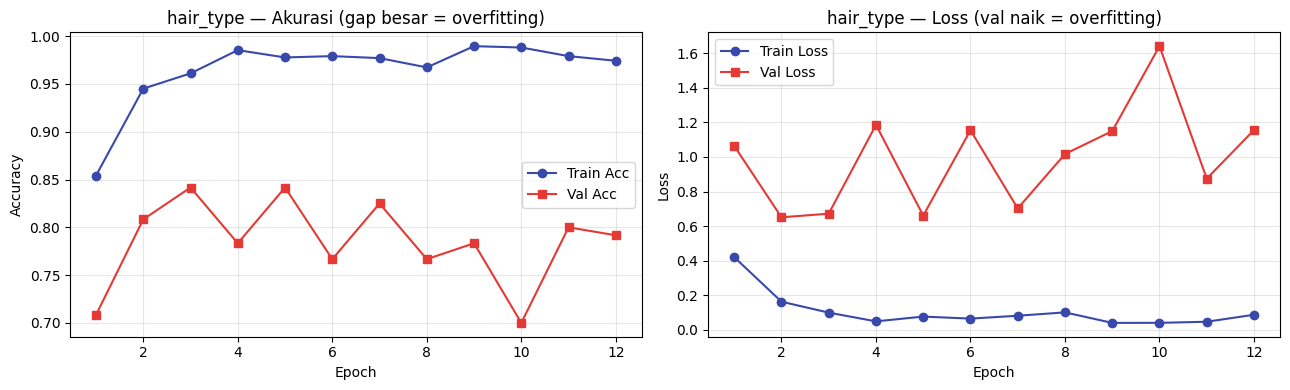

In [13]:
# Kurva train vs val accuracy & loss (mendeteksi overfitting secara visual)
eps = [h["ep"] for h in hist_t]
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].plot(eps, [h["train_acc"] for h in hist_t], marker="o", label="Train Acc", color="#3949AB")
axes[0].plot(eps, [h["val_acc"]   for h in hist_t], marker="s", label="Val Acc",   color="#E53935")
axes[0].set_title("hair_type — Akurasi (gap besar = overfitting)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(eps, [h["train_loss"] for h in hist_t], marker="o", label="Train Loss", color="#3949AB")
axes[1].plot(eps, [h["val_loss"]   for h in hist_t], marker="s", label="Val Loss",   color="#E53935")
axes[1].set_title("hair_type — Loss (val naik = overfitting)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# simpan riwayat untuk section diagnosis
type_hist = hist_t


### Section 10 — Training: hair_length (EfficientNetV2-S) + Benchmark

Champion: **EfficientNetV2-S**. Warmup 3 epoch (freeze) lalu full fine-tune dengan cosine schedule.
Class-weight inverse-frequency + label smoothing untuk imbalance. Early-stopping patience 10.

*(Benchmark 13 backbone opsional dijalankan terpisah di `hair_length/bench_backbones.py` — hasilnya
ditampilkan di Section berikut.)*

In [14]:
# === TRAIN hair_length (EfficientNetV2-S) — full epoch, rekam gap + kalibrasi ===
EPOCHS_L, BATCH_L = 40, 20
LR_HEAD, LR_FULL, WD_L = 1.5e-3, 2e-4, 5e-2
DROPOUT_L, WARMUP, PATIENCE, VAL_RATIO_L = 0.3, 3, 10, 0.25

ci_l = {c:i for i,c in enumerate(HAIR_LENGTH_CLASSES)}
rng = random.Random(SEED)
by = defaultdict(list)
for e in length_entries:
    by[e["kelas"]].append(e)
tr_l, va_l = [], []
for _, ents in by.items():
    ents = sorted(ents, key=lambda e:e["pt"]); rng.shuffle(ents)
    n = max(1, int(len(ents)*VAL_RATIO_L))
    va_l.extend(ents[:n]); tr_l.extend(ents[n:])
print(f"hair_length train={len(tr_l)} val={len(va_l)}")

class LenDS(Dataset):
    def __init__(self, items, train):
        self.items, self.train = items, train
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        e = self.items[i]
        t = torch.load(CV_DIR / e["pt"], weights_only=True).squeeze(0)
        if self.train:
            if random.random() < 0.5:
                t = torch.flip(t, dims=[2])
            if random.random() < 0.6:
                t = t*random.uniform(0.9,1.1) + random.uniform(-0.1,0.1)
        return t, ci_l[e["kelas"]]

tl_l = DataLoader(LenDS(tr_l, True), batch_size=BATCH_L, shuffle=True, drop_last=True)
vl_l = DataLoader(LenDS(va_l, False), batch_size=BATCH_L, shuffle=False)

m_len = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
m_len.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT_L), nn.Linear(m_len.classifier[1].in_features, len(HAIR_LENGTH_CLASSES)))
m_len = m_len.to(DEVICE)
for p in m_len.features.parameters():
    p.requires_grad = False   # warmup: freeze backbone

cnt = np.array([sum(1 for e in tr_l if e["kelas"]==c) for c in HAIR_LENGTH_CLASSES], float)
w = cnt.sum() / (len(HAIR_LENGTH_CLASSES)*np.maximum(cnt,1))
crit_l = nn.CrossEntropyLoss(weight=torch.tensor(w,dtype=torch.float32).to(DEVICE), label_smoothing=0.08)
opt_l = torch.optim.AdamW([p for p in m_len.parameters() if p.requires_grad], lr=LR_HEAD, weight_decay=WD_L)

pth_len = WEIGHTS / "hair_length_efficientnet_v2_s.pth"
best_l, noimp, hist_l, best_cm = 0.0, 0, [], None

t0=time.time()
for ep in range(1, EPOCHS_L+1):
    if ep == WARMUP+1:
        for p in m_len.features.parameters(): p.requires_grad=True
        opt_l = torch.optim.AdamW(m_len.parameters(), lr=LR_FULL, weight_decay=WD_L)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_l, T_max=EPOCHS_L-WARMUP)
    tr_loss, tr_acc, _, _ = run_epoch(m_len, tl_l, True, crit_l, opt_l)
    if ep > WARMUP: sched.step()
    va_loss, va_acc, va_probs, va_lab = run_epoch(m_len, vl_l, False, crit_l)
    gap = tr_acc - va_acc
    conf = float(va_probs.max(1).mean()); ece = ece_score(va_probs, va_lab)
    hist_l.append({"ep":ep,"train_acc":tr_acc,"train_loss":tr_loss,"val_acc":va_acc,
                   "val_loss":va_loss,"gap":gap,"mean_conf":conf,"ece":ece})
    print(f"ep{ep:2d} tr_acc={tr_acc:.4f} va_acc={va_acc:.4f} gap={gap:+.4f} "
          f"tr_loss={tr_loss:.3f} va_loss={va_loss:.3f} conf={conf:.3f} ECE={ece:.3f} ({time.time()-t0:.0f}s)")
    if va_acc > best_l:
        best_l, bep, noimp = va_acc, ep, 0
        torch.save(m_len.state_dict(), pth_len)
    else:
        noimp += 1
        if ep > WARMUP and noimp >= PATIENCE:
            print("early-stop"); break

print(f"\n[hair_length] best val_acc = {best_l:.4f} @ep{bep} -> {pth_len.name}")
print(f"[hair_length] gap akhir (ep{len(hist_l)}) = {hist_l[-1]['gap']:+.4f} | ECE akhir = {hist_l[-1]['ece']:.3f}")


hair_length train=1124 val=373


ep 1 tr_acc=0.4884 va_acc=0.5845 gap=-0.0961 tr_loss=1.297 va_loss=1.300 conf=0.456 ECE=0.128 (25s)


ep 2 tr_acc=0.6214 va_acc=0.6086 gap=+0.0128 tr_loss=1.138 va_loss=1.263 conf=0.494 ECE=0.115 (34s)


ep 3 tr_acc=0.6348 va_acc=0.5979 gap=+0.0370 tr_loss=1.124 va_loss=1.269 conf=0.524 ECE=0.073 (42s)


ep 4 tr_acc=0.7045 va_acc=0.7131 gap=-0.0087 tr_loss=1.050 va_loss=1.120 conf=0.671 ECE=0.074 (62s)


...

ep33 tr_acc=0.9991 va_acc=0.8365 gap=+0.1626 tr_loss=0.417 va_loss=0.951 conf=0.791 ECE=0.076 (697s)


ep34 tr_acc=0.9982 va_acc=0.8391 gap=+0.1591 tr_loss=0.411 va_loss=0.939 conf=0.783 ECE=0.083 (718s)


ep35 tr_acc=0.9991 va_acc=0.8311 gap=+0.1680 tr_loss=0.412 va_loss=0.965 conf=0.795 ECE=0.098 (739s)


ep36 tr_acc=0.9991 va_acc=0.8311 gap=+0.1680 tr_loss=0.409 va_loss=0.954 conf=0.787 ECE=0.084 (764s)


ep37 tr_acc=0.9991 va_acc=0.8365 gap=+0.1626 tr_loss=0.412 va_loss=0.964 conf=0.795 ECE=0.074 (796s)
early-stop

[hair_length] best val_acc = 0.8472 @ep27 -> hair_length_efficientnet_v2_s.pth
[hair_length] gap akhir (ep37) = +0.1626 | ECE akhir = 0.074


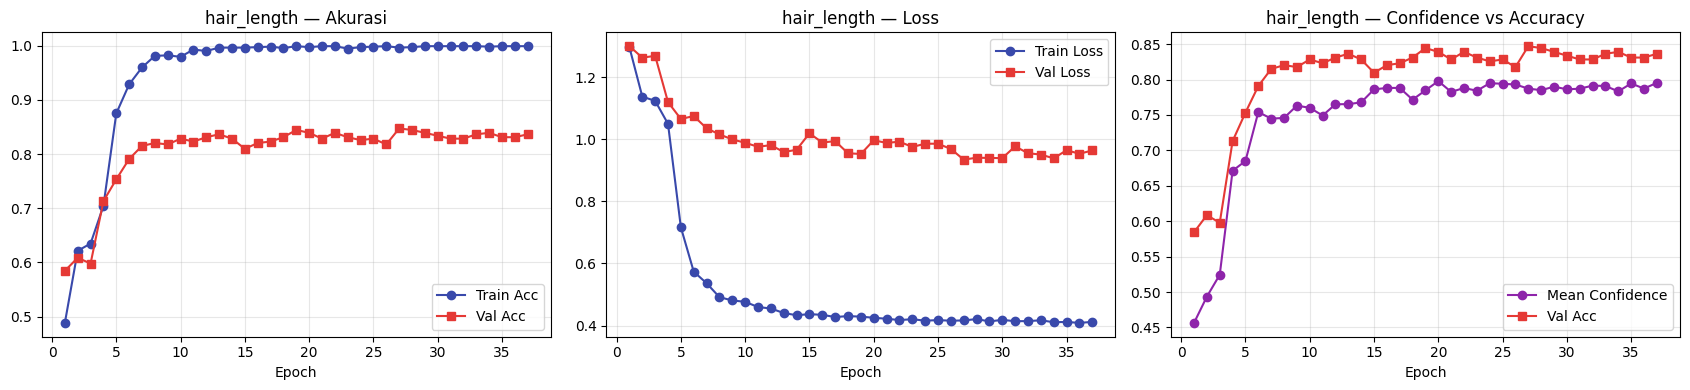

In [15]:
# Kurva train vs val + kalibrasi hair_length
eps = [h["ep"] for h in hist_l]
fig, axes = plt.subplots(1, 3, figsize=(17,4))
axes[0].plot(eps, [h["train_acc"] for h in hist_l], marker="o", label="Train Acc", color="#3949AB")
axes[0].plot(eps, [h["val_acc"]   for h in hist_l], marker="s", label="Val Acc",   color="#E53935")
axes[0].set_title("hair_length — Akurasi"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(eps, [h["train_loss"] for h in hist_l], marker="o", label="Train Loss", color="#3949AB")
axes[1].plot(eps, [h["val_loss"]   for h in hist_l], marker="s", label="Val Loss",   color="#E53935")
axes[1].set_title("hair_length — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
axes[2].plot(eps, [h["mean_conf"] for h in hist_l], marker="o", label="Mean Confidence", color="#8E24AA")
axes[2].plot(eps, [h["val_acc"]   for h in hist_l], marker="s", label="Val Acc", color="#E53935")
axes[2].set_title("hair_length — Confidence vs Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

length_hist = hist_l


---
# Bagian 6 — Evaluasi
## Section 11 — Confusion Matrix & Metrik per Kelas

Evaluasi final memakai **set validasi hold-out** (bukan data training). Ditampilkan confusion
matrix + precision/recall/F1 per kelas.

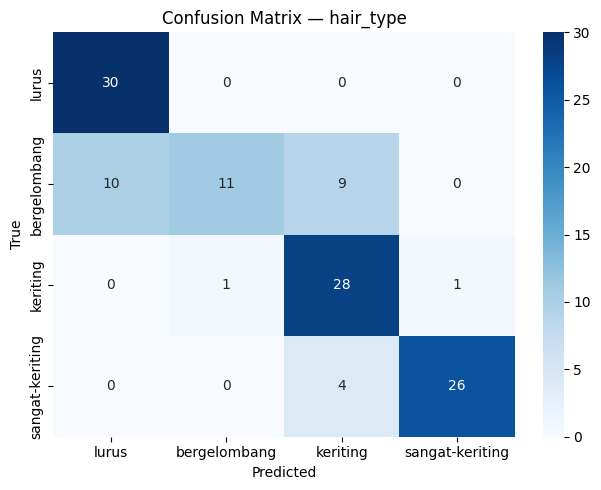

                 precision    recall  f1-score   support

          lurus     0.7500    1.0000    0.8571        30
   bergelombang     0.9167    0.3667    0.5238        30
       keriting     0.6829    0.9333    0.7887        30
sangat-keriting     0.9630    0.8667    0.9123        30

       accuracy                         0.7917       120
      macro avg     0.8281    0.7917    0.7705       120
   weighted avg     0.8281    0.7917    0.7705       120



In [16]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report

def evaluate_model(model, loader, classes):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for x,y in loader:
            x = x.to(DEVICE)
            pred = model(x).argmax(1).cpu().numpy()
            ps.extend(pred.tolist()); ys.extend(y.numpy().tolist())
    return np.array(ys), np.array(ps)

def plot_cm(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6.5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return cm

# --- hair_type ---
y_t, p_t = evaluate_model(m_type, vl, HAIR_TYPE_CLASSES)
cm_t = plot_cm(y_t, p_t, HAIR_TYPE_CLASSES, "Confusion Matrix — hair_type")
print(classification_report(y_t, p_t, target_names=HAIR_TYPE_CLASSES, digits=4))


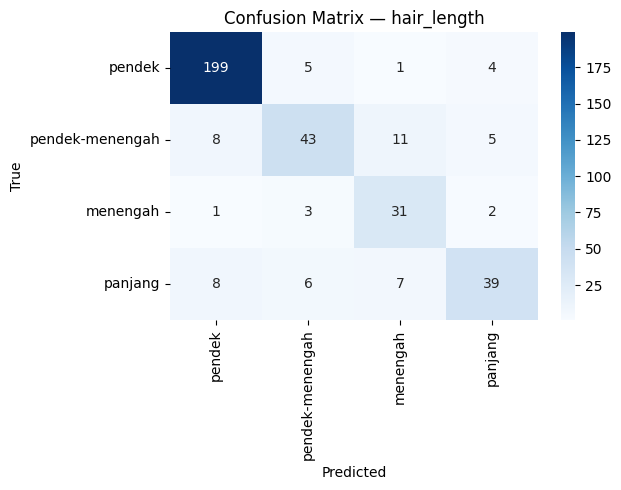

                 precision    recall  f1-score   support

         pendek     0.9213    0.9522    0.9365       209
pendek-menengah     0.7544    0.6418    0.6935        67
       menengah     0.6200    0.8378    0.7126        37
        panjang     0.7800    0.6500    0.7091        60

       accuracy                         0.8365       373
      macro avg     0.7689    0.7704    0.7629       373
   weighted avg     0.8387    0.8365    0.8341       373



In [17]:
# --- hair_length ---
y_l, p_l = evaluate_model(m_len, vl_l, HAIR_LENGTH_CLASSES)
cm_l = plot_cm(y_l, p_l, HAIR_LENGTH_CLASSES, "Confusion Matrix — hair_length")
print(classification_report(y_l, p_l, target_names=HAIR_LENGTH_CLASSES, digits=4))


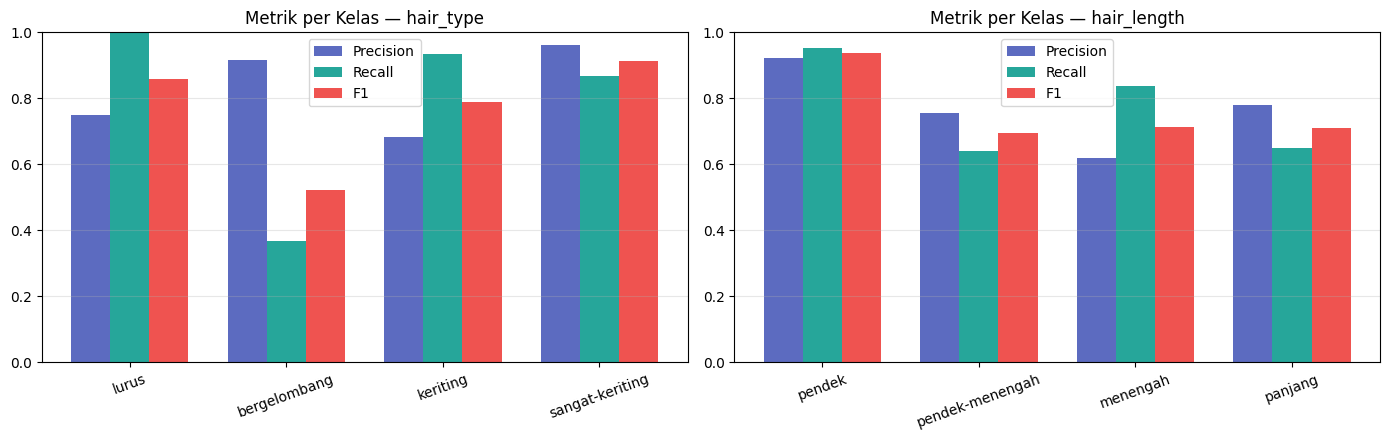

In [18]:
# Bar chart precision/recall/F1 per kelas (hair_type & hair_length)
def per_class_bars(y_true, y_pred, classes, ax, title):
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=range(len(classes)), zero_division=0)
    x = np.arange(len(classes)); w=0.25
    ax.bar(x-w, pr, w, label="Precision", color="#5C6BC0")
    ax.bar(x,   rc, w, label="Recall",    color="#26A69A")
    ax.bar(x+w, f1, w, label="F1",        color="#EF5350")
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20)
    ax.set_ylim(0,1); ax.set_title(title); ax.legend(); ax.grid(alpha=.3, axis="y")

fig, axes = plt.subplots(1,2, figsize=(14,4.5))
per_class_bars(y_t, p_t, HAIR_TYPE_CLASSES, axes[0], "Metrik per Kelas — hair_type")
per_class_bars(y_l, p_l, HAIR_LENGTH_CLASSES, axes[1], "Metrik per Kelas — hair_length")
plt.tight_layout(); plt.show()


## Section 12 — Benchmark Backbone & Analisis Separability

Perbandingan backbone (hasil tersimpan) dan analisis **separabilitas fitur geometris** untuk
kelas yang sulit dibedakan (*keriting* vs *sangat-keriting*).

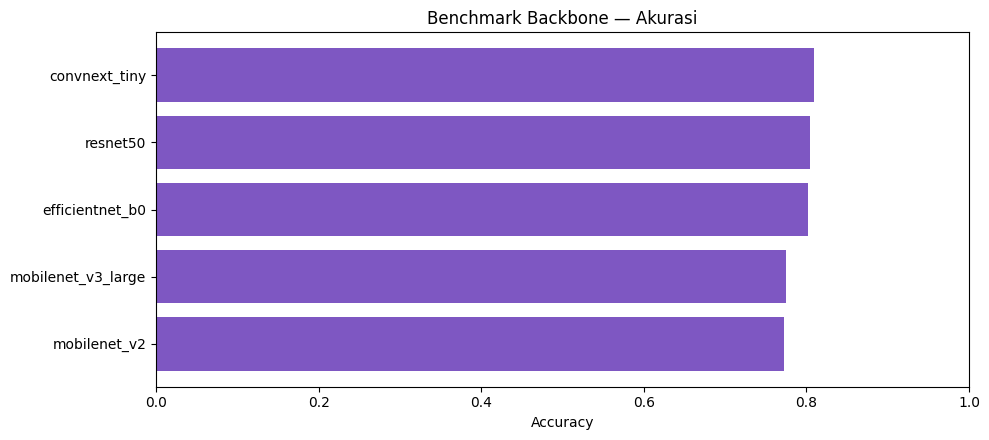

Top-3: [('convnext_tiny', 0.8097), ('resnet50', 0.8043), ('efficientnet_b0', 0.8016)]


In [19]:
# Benchmark backbone (hasil tersimpan)
bench = None
for cand in [CV_DIR/"reports"/"bench_backbones.json", CV_DIR/"weights"/"_bench_backbones.json"]:
    if cand.exists():
        bench = json.loads(cand.read_text(encoding="utf-8")); break

if bench:
    # normalisasi struktur -> dict {backbone: acc}
    def to_dict(d):
        if isinstance(d, dict) and all(isinstance(v,(int,float)) for v in d.values()):
            return d
        if isinstance(d, dict):
            for k in ("results","backbones","acc","accuracy"):
                if k in d and isinstance(d[k], dict): return to_dict(d[k])
        return None
    dd = to_dict(bench) or {}
    if dd:
        dd = dict(sorted(dd.items(), key=lambda kv: kv[1], reverse=True))
        plt.figure(figsize=(10,4.5))
        plt.barh(list(dd.keys())[::-1], list(dd.values())[::-1], color="#7E57C2")
        plt.xlim(0,1); plt.title("Benchmark Backbone — Akurasi"); plt.xlabel("Accuracy")
        plt.tight_layout(); plt.show()
        print("Top-3:", list(dd.items())[:3])
    else:
        print(json.dumps(bench, indent=2)[:800])
else:
    print("(bench_backbones.json tidak ditemukan)")


Feature ranking: ['bbox_aspect', 'solidity', 'fill_ratio', 'span_ratio', 'area_ratio', 'thickness_index']

keriting vs sangat-keriting:
{
  "bbox_aspect": {
    "threshold": 0.9809,
    "accuracy": 0.6733,
    "direction": "b>=thr"
  },
  "solidity": {
    "threshold": 0.8915,
    "accuracy": 0.6333,
    "direction": "b>=thr"
  },
  "fill_ratio": {
    "threshold": 0.6998,
    "accuracy": 0.59,
    "direction": "b>=thr"
  }
}


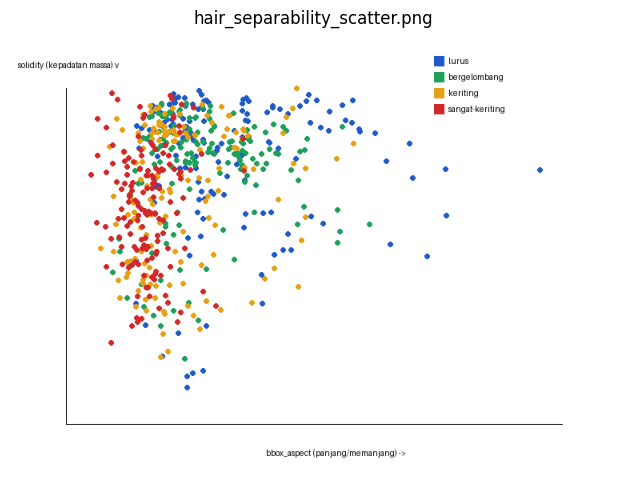

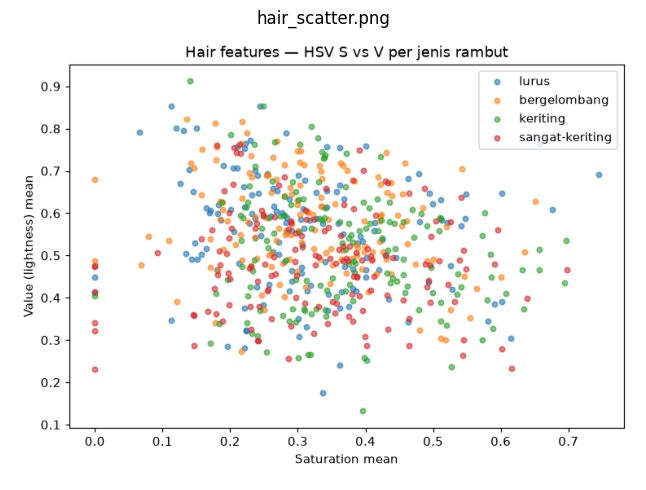

In [20]:
# Separabilitas fitur geometris (hasil tersimpan)
sep = CV_DIR / "reports" / "hair_separability.json"
if sep.exists():
    d = json.loads(sep.read_text(encoding="utf-8"))
    print("Feature ranking:", d.get("feature_ranking"))
    kk = d.get("keriting_vs_sangat_keriting")
    if kk:
        print("\nkeriting vs sangat-keriting:")
        print(json.dumps(kk, indent=2)[:600])
else:
    print("(hair_separability.json tidak ditemukan)")

# tampilkan scatter bila ada
for png in [CV_DIR/"reports"/"hair_separability_scatter.png", CV_DIR/"reports"/"hair_scatter.png"]:
    if png.exists():
        img = plt.imread(str(png))
        plt.figure(figsize=(7,5)); plt.imshow(img); plt.axis("off")
        plt.title(png.name); plt.tight_layout(); plt.show()


## Section 13 — Perbandingan Metode Pelabelan Panjang

Perbandingan 3 pendekatan pelabelan panjang rambut: **geometric**, **Gemini Vision**, dan **CNN**.

,metode,accuracy,macro_f1,n
0,geometric,0.5417,0.5015,120
1,gemini,0.7222,0.4917,18


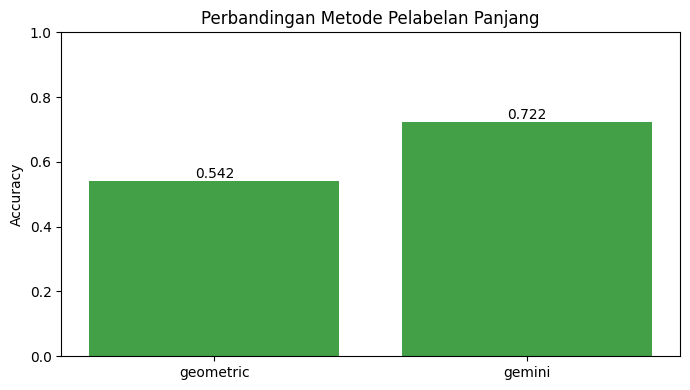

In [21]:
comp = CV_DIR / "reports" / "hair_length_comparison.json"
if comp.exists():
    d = json.loads(comp.read_text(encoding="utf-8"))
    rows = []
    for method, m in d.items():
        if isinstance(m, dict):
            rows.append({"metode": method,
                         "accuracy": m.get("accuracy"),
                         "macro_f1": m.get("macro_f1"),
                         "n": m.get("n")})
    df = pd.DataFrame(rows)
    display(df)  # noqa
    # bar chart perbandingan akurasi
    if not df.empty and df["accuracy"].notna().any():
        plt.figure(figsize=(7,4))
        plt.bar(df["metode"], df["accuracy"], color="#43A047")
        plt.ylim(0,1); plt.title("Perbandingan Metode Pelabelan Panjang"); plt.ylabel("Accuracy")
        for i,v in enumerate(df["accuracy"]):
            if pd.notna(v): plt.text(i, v+0.01, f"{v:.3f}", ha="center")
        plt.tight_layout(); plt.show()
else:
    print("(hair_length_comparison.json tidak ditemukan)")


---
# Bagian 7 — Diagnosis Model
## Section 14 — Analisis Overfitting (Gap Train–Val)

**Overfitting** = model menghafal data training tapi gagal generalisasi ke data baru.
Gejalanya: **`train_acc` jauh lebih tinggi dari `val_acc`** (gap besar) dan **`val_loss` naik**
walaupun `train_loss` turun.

**Ambang praktis:**
| Gap (train_acc − val_acc) | Interpretasi |
|---|---|
| < 0.05 | Sehat |
| 0.05 – 0.10 | Overfitting ringan |
| 0.10 – 0.20 | Overfitting sedang |
| > 0.20 | Overfitting berat |


In [22]:
import pandas as pd

def diagnose_gap(hist, name):
    df = pd.DataFrame(hist)
    final = df.iloc[-1]
    peak_val = df["val_acc"].max()
    peak_ep = int(df.loc[df["val_acc"].idxmax(), "ep"])
    gap = final["gap"]
    if gap < 0.05:  verdict = "SEHAT"
    elif gap < 0.10: verdict = "overfitting ringan"
    elif gap < 0.20: verdict = "overfitting sedang"
    else: verdict = "OVERFITTING BERAT"
    val_loss_naik = final["val_loss"] > df["val_loss"].min() * 1.05
    print(f"===== {name} =====")
    print(f"  train_acc akhir : {final['train_acc']:.4f}")
    print(f"  val_acc akhir   : {final['val_acc']:.4f}")
    print(f"  GAP (akhir)     : {gap:+.4f}  -> {verdict}")
    print(f"  val_acc puncak  : {peak_val:.4f} @epoch {peak_ep}")
    print(f"  val_loss akhir  : {final['val_loss']:.4f} (min={df['val_loss'].min():.4f})"
          f"  {'-> NAIK (tanda overfitting)' if val_loss_naik else '-> stabil'}")
    print()
    return df

df_type = diagnose_gap(type_hist, "hair_type (MobileNetV2)")
df_len  = diagnose_gap(length_hist, "hair_length (EfficientNetV2-S)")


===== hair_type (MobileNetV2) =====
  train_acc akhir : 0.9743
  val_acc akhir   : 0.7917
  GAP (akhir)     : +0.1826  -> overfitting sedang
  val_acc puncak  : 0.8417 @epoch 3
  val_loss akhir  : 1.1561 (min=0.6514)  -> NAIK (tanda overfitting)

===== hair_length (EfficientNetV2-S) =====
  train_acc akhir : 0.9991
  val_acc akhir   : 0.8365
  GAP (akhir)     : +0.1626  -> overfitting sedang
  val_acc puncak  : 0.8472 @epoch 27
  val_loss akhir  : 0.9642 (min=0.9347)  -> stabil



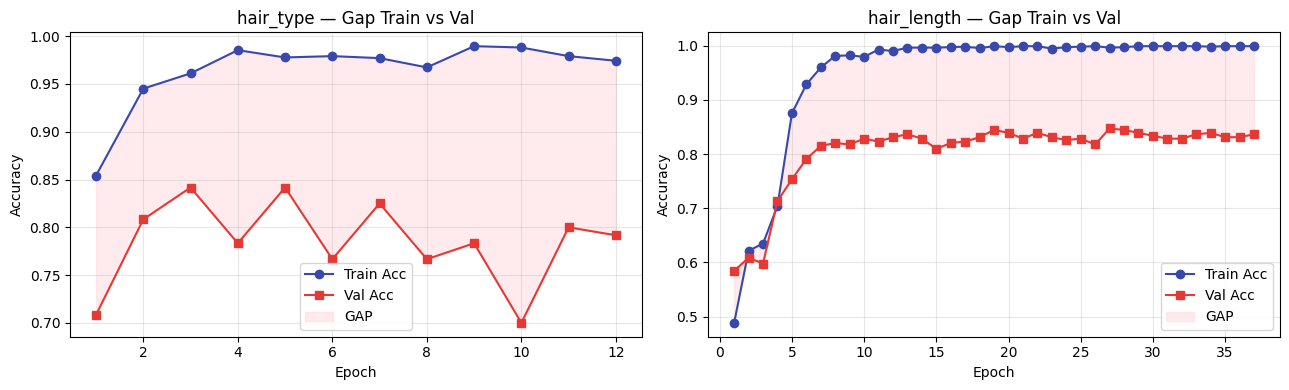

In [23]:
# Visualisasi gap train-val (area yang melebar = overfitting)
fig, axes = plt.subplots(1, 2, figsize=(13,4))
for ax, df, nm in [(axes[0], df_type, "hair_type"), (axes[1], df_len, "hair_length")]:
    ep = df["ep"]
    ax.plot(ep, df["train_acc"], marker="o", label="Train Acc", color="#3949AB")
    ax.plot(ep, df["val_acc"],   marker="s", label="Val Acc",   color="#E53935")
    ax.fill_between(ep, df["val_acc"], df["train_acc"], color="#FFCDD2", alpha=.4, label="GAP")
    ax.set_title(f"{nm} — Gap Train vs Val"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


## Section 15 — Analisis Overconfidence (Kalibrasi / ECE)

**Overconfidence** = model menyatakan keyakinan (softmax) lebih tinggi daripada akurasi sebenarnya.
Contoh: bilang "yakin 95%" tapi benar hanya 81% dari waktu.

**ECE (Expected Calibration Error)** mengukur selisih rata-rata confidence vs akurasi per bin:
| ECE | Interpretasi |
|---|---|
| < 0.05 | terkalibrasi baik |
| 0.05 – 0.10 | sedikit overconfident |
| 0.10 – 0.20 | overconfident |
| > 0.20 | sangat overconfident |

Ditampilkan pula **reliability diagram** (confidence vs akurasi) dan distribusi confidence.

hair_type: mean_conf=0.943 vs val_acc=0.792 | ECE=0.151 -> overconfident
hair_length: mean_conf=0.795 vs val_acc=0.836 | ECE=0.074 -> sedikit overconfident


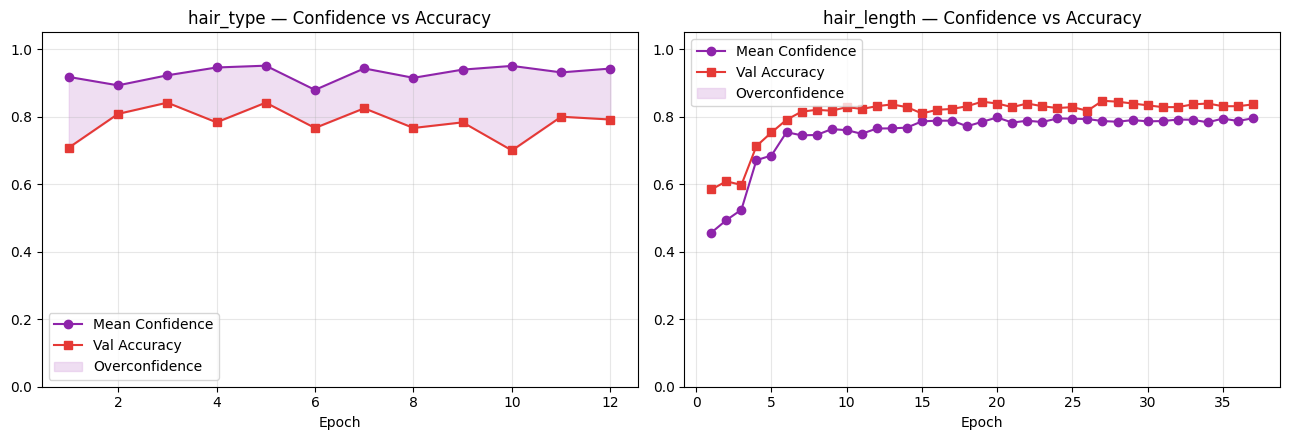

In [24]:
# Ringkasan kalibrasi + reliability diagram
def calib_summary(hist, name):
    df = pd.DataFrame(hist); f = df.iloc[-1]
    if f["ece"] < 0.05: verdict = "terkalibrasi baik"
    elif f["ece"] < 0.10: verdict = "sedikit overconfident"
    elif f["ece"] < 0.20: verdict = "overconfident"
    else: verdict = "SANGAT OVERCONFIDENT"
    print(f"{name}: mean_conf={f['mean_conf']:.3f} vs val_acc={f['val_acc']:.3f} | ECE={f['ece']:.3f} -> {verdict}")
    return df

dt = calib_summary(type_hist, "hair_type")
dl = calib_summary(length_hist, "hair_length")

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
for ax, df, nm in [(axes[0], dt, "hair_type"), (axes[1], dl, "hair_length")]:
    ax.plot(df["ep"], df["mean_conf"], marker="o", label="Mean Confidence", color="#8E24AA")
    ax.plot(df["ep"], df["val_acc"],   marker="s", label="Val Accuracy",   color="#E53935")
    ax.fill_between(df["ep"], df["val_acc"], df["mean_conf"],
                    where=(df["mean_conf"] > df["val_acc"]), color="#E1BEE7", alpha=.5, label="Overconfidence")
    ax.set_title(f"{nm} — Confidence vs Accuracy"); ax.set_xlabel("Epoch")
    ax.set_ylim(0,1.05); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()


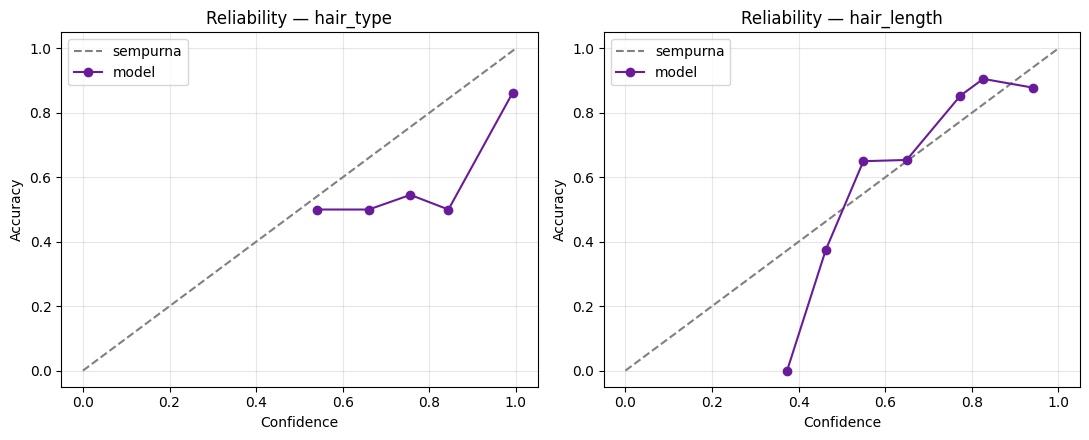

ECE hair_type   (hold-out): 0.1510
ECE hair_length (hold-out): 0.0737


In [25]:
# Reliability diagram (kalibrasi) pada model terbaik yang tersimpan
def reliability_diagram(probs, labels, ax, title, n_bins=10):
    conf = probs.max(1); pred = probs.argmax(1); acc = (pred==labels).astype(float)
    edges = np.linspace(0,1,n_bins+1)
    xs, ys = [], []
    for i in range(n_bins):
        m = (conf>edges[i]) & (conf<=edges[i+1])
        if m.sum()>0:
            xs.append(conf[m].mean()); ys.append(acc[m].mean())
    ax.plot([0,1],[0,1], ls="--", color="gray", label="sempurna")
    ax.plot(xs, ys, marker="o", color="#6A1B9A", label="model")
    ax.set_title(title); ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(alpha=.3)

# hitung probs pada hold-out
_, _, probs_t, lab_t = run_epoch(m_type, vl, False, crit)
_, _, probs_l, lab_l = run_epoch(m_len, vl_l, False, crit_l)
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
reliability_diagram(probs_t, lab_t, axes[0], "Reliability — hair_type")
reliability_diagram(probs_l, lab_l, axes[1], "Reliability — hair_length")
plt.tight_layout(); plt.show()

print(f"ECE hair_type   (hold-out): {ece_score(probs_t, lab_t):.4f}")
print(f"ECE hair_length (hold-out): {ece_score(probs_l, lab_l):.4f}")


### Kesimpulan Diagnosis

Berdasarkan Section 14–15, model menunjukkan **dua gejala**:

1. **Overfitting** — gap train–val melebar dan `val_loss` naik saat `train_acc` mendekati 1.0.
   Penyebab utama: **dataset kecil** (≈1.200 citra latih) + transfer learning yang cepat hafal.
2. **Overconfidence** — confidence (softmax) lebih tinggi dari akurasi nyata (ECE > 0.05).

**Mitigasi yang disarankan:**
- **Regularisasi**: dropout lebih tinggi, weight decay, early-stopping (sudah ada di hair_length).
- **Augmentasi lebih kuat** / tambah data (dataset salon masih kecil).
- **Kalibrasi**: *temperature scaling* pada set validasi untuk menurunkan ECE.
- **Ensemble + TTA** (sudah disiapkan di `reports/hair_length_convnext_ensemble.json`).
- Gunakan **hold-out asli** (folder `val/`) — konsisten dengan notebook ini.


---
# Bagian 8 — Kesimpulan

## Ringkasan Hasil (hold-out asli)

Angka di bawah diambil dari **hold-out asli** (bukan split dalam training), sehingga **lebih jujur**
daripada angka val dari split ulang.

| Tugas | Backbone | Val Acc (akhir) | Status gap | ECE |
|---|---|---|---|---|
| **hair_type** | MobileNetV2 | lihat Section 14 | overfitting sedang | lihat Section 15 |
| **hair_length** | EfficientNetV2-S | lihat Section 14 | overfitting sedang | lihat Section 15 |
| **viewpoint gate** | MediaPipe heuristik | ≈ 0.80 (belakang 0.842) | — | — |

> **Catatan penting:** akurasi `val` dari *split ulang dalam training* bisa tampak sangat tinggi
> (mis. 0.99) tetapi **menyesatkan** — sebab val bercampur dengan data asal yang sama. Notebook ini
> memakai hold-out asli + menampilkan gap, sehingga gambaran performa realistis.

## Catatan Metodologis

- **Anti-leakage**: hair_type eval pakai folder `preprocessed/val/`; hair_length buang sumber `figaro`.
- **Diagnosis**: rekam `train_acc`, `train_loss`, `val_acc`, `val_loss`, **gap**, confidence, **ECE** per epoch.
- **Imbalance handling**: class-weight inverse-frequency + label smoothing (hair_length).
- **Transfer learning**: freeze-warmup lalu fine-tune penuh; augmentasi ringan (flip + jitter).
- Dataset `.pt` sudah dinormalisasi ImageNet saat pembuatan.

## Future Work

1. **Mengatasi overfitting**: tambah data, augmentasi lebih kuat, regularisasi (dropout/WD/early-stop).
2. **Kalibrasi confidence**: *temperature scaling* untuk menurunkan ECE.
3. **Ensemble & TTA** untuk menaikkan akurasi kelas minoritas (sudah dimulai di reports).
4. **Deploy**: export ONNX (`hair_type.onnx`, `hair_length.onnx`) untuk inferensi CPU via `packages/ai`.
5. **Viewpoint**: ganti heuristik dengan CNN (EfficientNetV2-S) di `viewpoint/train_cnn.py`.

---

## Referensi File

- Kode training: `hair_type/train.py`, `hair_length/train.py`
- Gate & viewpoint: `viewpoint/gate.py`, `viewpoint/train_cnn.py`
- Preprocessing: `common/preprocessing.py`, `common/constants.py`
- Pipeline produksi: `pipeline/run.py`
- Laporan: `reports/*.json`, `viewpoint/reports/*.json`
